<a href="https://colab.research.google.com/github/rag-dev1511/PREDICTIVE-ANALYSIS-101/blob/main/predictive_analytics_flights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Analytics Using Historical Data
Forecasting monthly airline passengers (1949-1960) with Linear Regression and Holt-Winters (time-series).

## Step 1: Import libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sns.set_theme(style="whitegrid")

## Step 2: Load and explore the data

In [22]:
df = sns.load_dataset("flights")
print(df.head())
print()
df.info()
print()
print(df.describe())

   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB

              year  passengers
count   144.000000  144.000000
mean   1954.500000  280.298611
std       3.464102  119.966317
min    1949.000000  104.000000
25%    1951.750000  180.000000
50%    1954.500000  265.500000
75%    1957.250000  360.500000
max    1960.000000  622.000000


## Step 3: Clean and preprocess

In [23]:
# Check data quality
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

# Combine year + month into a proper datetime column
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str) + "-01", format="%Y-%b-%d")

# Sort by date, set date as index, and set monthly frequency
df = df.sort_values("date").set_index("date").asfreq("MS")

# Feature for regression: a time counter (captures trend)
df["t"] = np.arange(len(df))
df["month_num"] = df.index.month

print(df.head())

Missing values:
 year          0
month         0
passengers    0
dtype: int64
Duplicate rows: 0
            year month  passengers  t  month_num
date                                            
1949-01-01  1949   Jan         112  0          1
1949-02-01  1949   Feb         118  1          2
1949-03-01  1949   Mar         132  2          3
1949-04-01  1949   Apr         129  3          4
1949-05-01  1949   May         121  4          5


## Step 4: Visualize the historical data

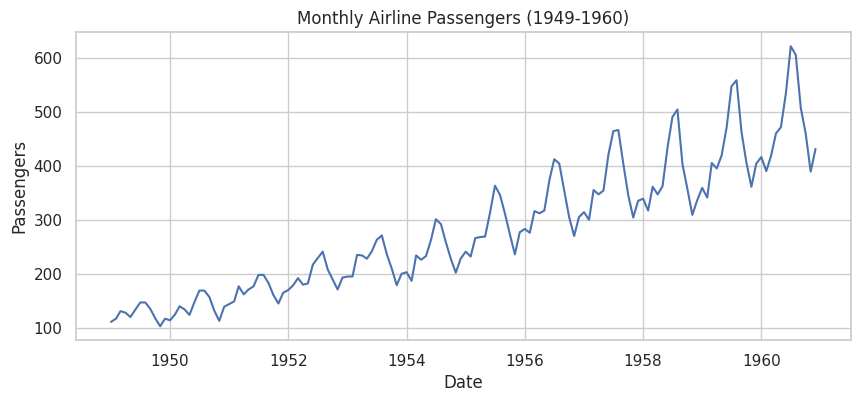

In [24]:
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["passengers"])
plt.title("Monthly Airline Passengers (1949-1960)")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.show()

**Observation:** passenger numbers rise steadily over time (trend) and repeat a yearly pattern (seasonality), with the swings getting larger as the numbers grow.

## Step 5: Split chronologically (no shuffling)

In [25]:
train = df[df.index.year <= 1958]
test = df[df.index.year >= 1959]
print("Train:", train.index.min().date(), "to", train.index.max().date(), "| rows:", len(train))
print("Test: ", test.index.min().date(), "to", test.index.max().date(), "| rows:", len(test))

Train: 1949-01-01 to 1958-12-01 | rows: 120
Test:  1959-01-01 to 1960-12-01 | rows: 24


## Step 6: Model 1 - Linear Regression
Uses the time counter (trend) plus month dummies (seasonality).

In [26]:
def make_features(data):
    X = pd.get_dummies(data["month_num"], prefix="m", drop_first=True).astype(float)
    X["t"] = data["t"].values
    return X

X_train = make_features(train)
X_test = make_features(test).reindex(columns=X_train.columns, fill_value=0)

lr = LinearRegression()
lr.fit(X_train, train["passengers"])
lr_pred = pd.Series(lr.predict(X_test), index=test.index)

## Step 7: Model 2 - Holt-Winters (time-series)

In [27]:
hw = ExponentialSmoothing(train["passengers"], trend="add", seasonal="mul", seasonal_periods=12).fit()
hw_pred = hw.forecast(len(test))

## Step 8: Evaluate accuracy

In [28]:
def evaluate(name, actual, pred):
    return {
        "Model": name,
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": np.sqrt(mean_squared_error(actual, pred)),
        "R2": r2_score(actual, pred),
    }

results = pd.DataFrame([
    evaluate("Linear Regression", test["passengers"], lr_pred),
    evaluate("Holt-Winters", test["passengers"], hw_pred),
]).round(3)
results

,Model,MAE,RMSE,R2
0,Linear Regression,34.638,47.944,0.588
1,Holt-Winters,28.977,32.489,0.811


## Step 9: Visualize predictions

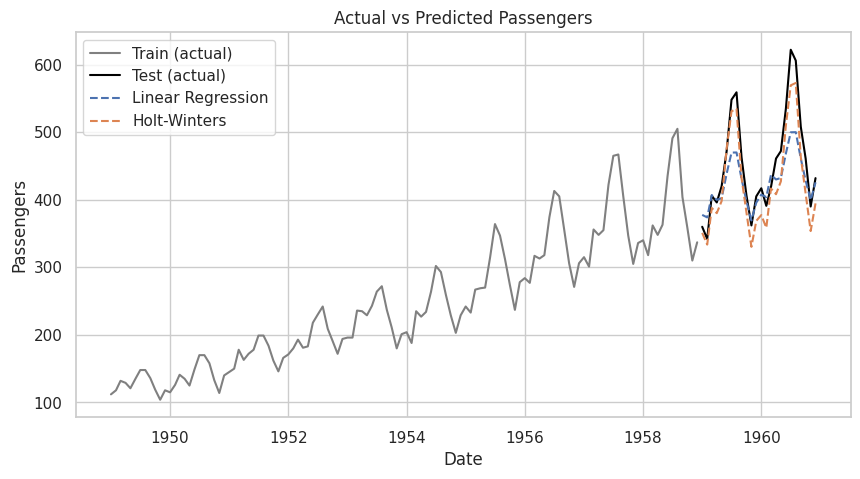

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(train.index, train["passengers"], label="Train (actual)", color="gray")
plt.plot(test.index, test["passengers"], label="Test (actual)", color="black")
plt.plot(lr_pred.index, lr_pred, label="Linear Regression", linestyle="--")
plt.plot(hw_pred.index, hw_pred, label="Holt-Winters", linestyle="--")
plt.title("Actual vs Predicted Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()

## Step 10: Forecast the future (24 months beyond the data)
Refit the better time-series model on all the data and forecast ahead.

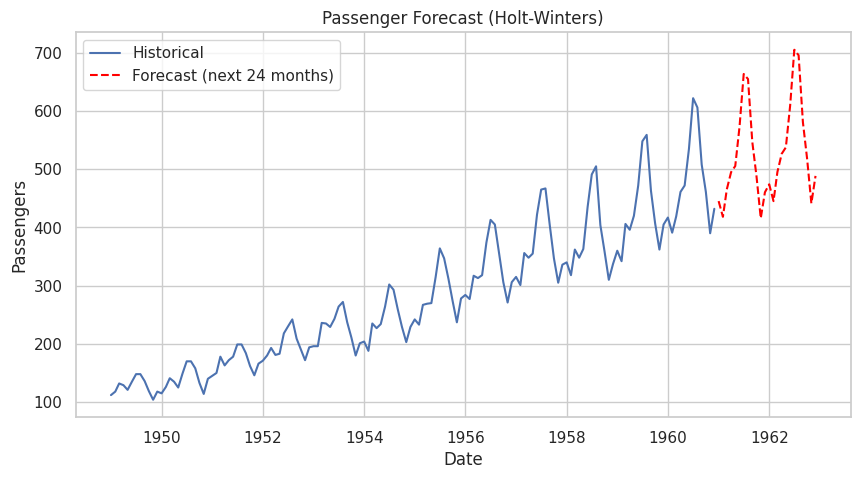

In [30]:
final_hw = ExponentialSmoothing(df["passengers"], trend="add", seasonal="mul", seasonal_periods=12).fit()
future = final_hw.forecast(24)

plt.figure(figsize=(10, 5))
plt.plot(df.index, df["passengers"], label="Historical")
plt.plot(future.index, future, label="Forecast (next 24 months)", linestyle="--", color="red")
plt.title("Passenger Forecast (Holt-Winters)")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()

## Step 11: Summary
RESULTS:
- **Data:** monthly passengers, 144 rows, clear upward trend and yearly seasonality.
- **Cleaning:** checked missing values and duplicates, converted year + month to datetime, set date as index.
- **Models:** Linear Regression (trend + month dummies) and Holt-Winters.
- **Best model:** (compare the MAE / RMSE / R2 table above).
- **Limitations:** small dataset (144 points), only one variable, forecasts assume past patterns continue.